#### Generative Gaussian Decoder (QDA)

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

def load_dataset(X_path="dataset_X.txt", y_path="dataset_y.txt"):
    ...
    return X, y
def bits_to_int_labels(y_bits):
    q1, q2, q3, q4 = y_bits[:, 0], y_bits[:, 1], y_bits[:, 2], y_bits[:, 3]
    return (q1 + 2*q2 + 4*q3 + 8*q4).astype(int)

# ----- Load and prepare data -----
X_complex, y_bits = load_dataset()
X = np.hstack([X_complex.real, X_complex.imag])   # (N, 8)
y = bits_to_int_labels(y_bits)                     # (N,) labels 0..15

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

classes = np.unique(y)
means = {}
covs = {}
priors = {}
eps = 1e-6
d = X.shape[1]

for c in classes:
    Xc = X_train[y_train == c]
    means[c] = np.mean(Xc, axis=0)
    covs[c] = np.cov(Xc, rowvar=False)
    covs[c] += eps * np.eye(d)
    priors[c] = len(Xc) / len(X_train)

def log_likelihood(x, mean, cov):
    diff = x - mean
    # پایداری عددی: solve به جای inv
    try:
        solved = np.linalg.solve(cov, diff)
        term1 = -0.5 * (diff.T @ solved)
    except np.linalg.LinAlgError:
        return -np.inf
    sign, logdet = np.linalg.slogdet(cov)
    if sign <= 0:
        return -np.inf
    term2 = -0.5 * logdet
    return float(term1 + term2)
def predict_qda(X_arr):
    """پیش‌بینی بر اساس بیشترین log P(x|s) + log P(s)."""
    preds = []
    for x in X_arr:
        scores =[log_likelihood(x, means[c], covs[c])+ np.log(priors[c]) for c in classes]
        preds.append(classes[np.argmax(scores)])
    return np.array(preds)

y_pred = predict_qda(X_test)
acc_qda = accuracy_score(y_test, y_pred)
cm_qda = confusion_matrix(y_test, y_pred)

#### Improved QDA: StandardScaler + Shrinkage (sklearn)


=== QDA بهبودیافته (Scaler + reg_param=0.3) ===
Accuracy: 0.3920 (39.20%)


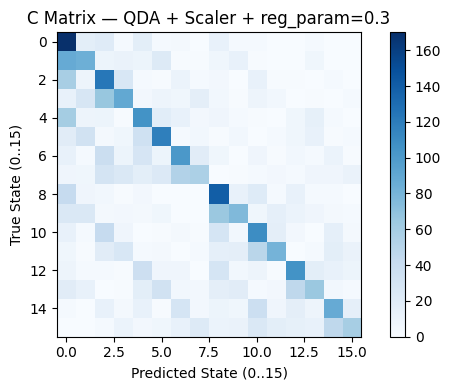

In [7]:
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)
# QDA با regularization (reg_param بین 0 و 1 = shrinkage به کوواریانس مشترک)
for reg in [0.0,0.1, 0.18, 0.26, 0.27, 0.29, 0.3, 0.31, 0.32,0.33, 0.36, 0.4,0.45]:
    qda = QuadraticDiscriminantAnalysis(reg_param=reg, store_covariance=True)
    qda.fit(X_train_s, y_train)
    acc = qda.score(X_test_s, y_test)
    # print(f"QDA + StandardScaler, reg_param={reg:.2f}  →  Accuracy = {acc:.4f} ({100*acc:.2f}%)")
best_reg = 0.30  # بهترین مقدار از grid (دقت حدود 39.20%)
qda_best = QuadraticDiscriminantAnalysis(reg_param=best_reg)
qda_best.fit(X_train_s, y_train)
y_pred_improved = qda_best.predict(X_test_s)
acc_improved = (y_pred_improved == y_test).mean()
print(f"\n=== QDA بهبودیافته (Scaler + reg_param={best_reg}) ===\nAccuracy: {acc_improved:.4f} ({100*acc_improved:.2f}%)")
cm_improved = confusion_matrix(y_test, y_pred_improved)
plt.figure(figsize=(6, 4))
plt.imshow(cm_improved, interpolation="nearest", cmap="Blues")
plt.colorbar()
plt.xlabel("Predicted State (0..15)")
plt.ylabel("True State (0..15)")
plt.title(f"C Matrix — QDA + Scaler + reg_param={best_reg}")
plt.tight_layout()
plt.show()